In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
from sklearn.metrics.pairwise import pairwise_distances

In [2]:
colour = {
    'g': np.array([0, 158, 115])/256,
    'b': np.array([0, 114, 178])/256,
    'lb': np.array([86, 180, 233])/256,
    'r': np.array([213, 94, 0])/256,
    'o': np.array([230, 159, 0])/256,
    'y': np.array([240, 228, 66])/256,
    'p': np.array([204, 121, 167])/256,
    }

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)
    

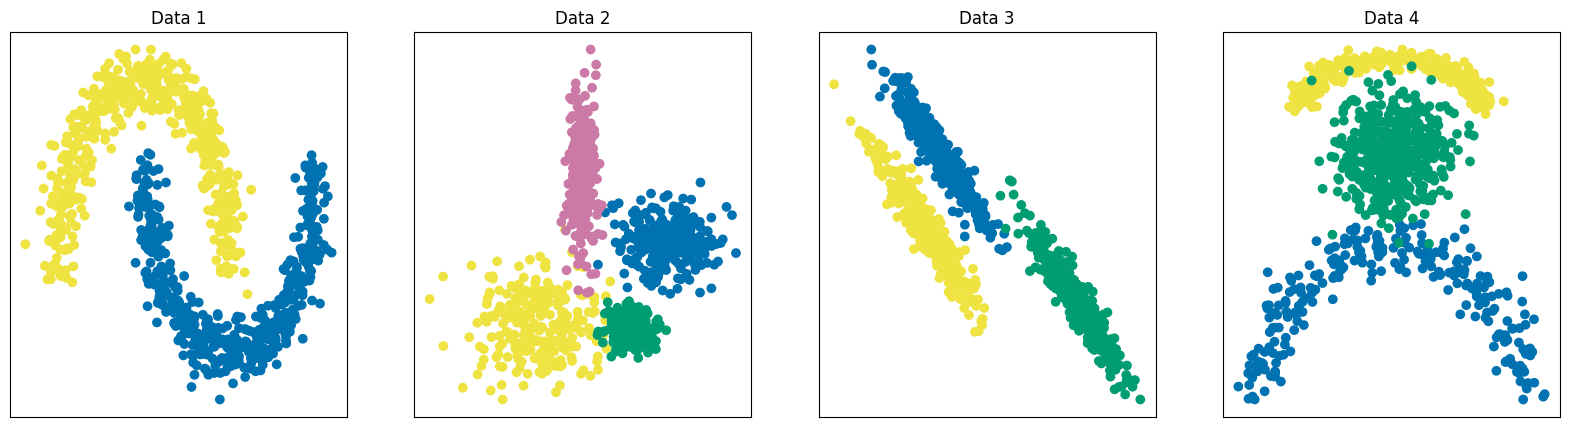

In [5]:
data1 = moons()
data2 = four_gaussians()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['b'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['g'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()


In [6]:
LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 2012.25341796875 | Validation Loss: 2011.2215576171875
Iteration 99 | Train Loss: 258.890380859375 | Validation Loss: 260.8229064941406
Iteration 199 | Train Loss: 223.1669464111328 | Validation Loss: 225.0566864013672
Iteration 299 | Train Loss: 206.1322784423828 | Validation Loss: 205.4815673828125
Iteration 399 | Train Loss: 205.5122833251953 | Validation Loss: 206.65509033203125
Iteration 499 | Train Loss: 186.6288604736328 | Validation Loss: 186.73236083984375
Iteration 599 | Train Loss: 184.04733276367188 | Validation Loss: 183.06942749023438
Iteration 699 | Train Loss: 181.8854522705078 | Validation Loss: 178.97235107421875
Iteration 799 | Train Loss: 180.82899475097656 | Validation Loss: 180.95620727539062
Iteration 899 | Train Loss: 181.24725341796875 | Validation Loss: 182.22613525390625
Iteration 999 | Train Loss: 178.58935546875 | Validation Loss: 179.23883056640625
Iteration 1099 | Train Loss: 179.95799255371094 | Validation Loss: 180.082229614257

In [7]:
LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1880.47802734375 | Validation Loss: 1880.79931640625
Iteration 99 | Train Loss: 258.9236755371094 | Validation Loss: 262.87261962890625
Iteration 199 | Train Loss: 200.08334350585938 | Validation Loss: 203.03085327148438
Iteration 299 | Train Loss: 192.7046661376953 | Validation Loss: 197.7786407470703
Iteration 399 | Train Loss: 193.3422088623047 | Validation Loss: 199.4369659423828
Iteration 499 | Train Loss: 191.44021606445312 | Validation Loss: 198.4280548095703
Iteration 599 | Train Loss: 190.78631591796875 | Validation Loss: 197.97158813476562
Iteration 699 | Train Loss: 189.72320556640625 | Validation Loss: 201.68971252441406
Iteration 799 | Train Loss: 189.17919921875 | Validation Loss: 203.52488708496094
Early stopping at iteration 799


In [8]:
LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1803.879150390625 | Validation Loss: 1802.164306640625
Iteration 99 | Train Loss: 222.74400329589844 | Validation Loss: 220.2350311279297
Iteration 199 | Train Loss: 178.03195190429688 | Validation Loss: 177.36129760742188
Iteration 299 | Train Loss: 164.49273681640625 | Validation Loss: 162.9635009765625
Iteration 399 | Train Loss: 137.53399658203125 | Validation Loss: 140.5667266845703
Iteration 499 | Train Loss: 130.5080108642578 | Validation Loss: 126.3576431274414
Iteration 599 | Train Loss: 127.38701629638672 | Validation Loss: 121.18270111083984
Iteration 699 | Train Loss: 126.55903625488281 | Validation Loss: 119.68194580078125
Iteration 799 | Train Loss: 126.2057876586914 | Validation Loss: 117.88188171386719
Iteration 899 | Train Loss: 125.49809265136719 | Validation Loss: 119.42235565185547
Iteration 999 | Train Loss: 125.1636734008789 | Validation Loss: 118.95758819580078
Iteration 1099 | Train Loss: 127.89291381835938 | Validation Loss: 126.319511

In [9]:
LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 2037.053466796875 | Validation Loss: 2039.1934814453125
Iteration 99 | Train Loss: 231.97412109375 | Validation Loss: 238.3629913330078
Iteration 199 | Train Loss: 234.19801330566406 | Validation Loss: 242.19508361816406
Iteration 299 | Train Loss: 228.0959014892578 | Validation Loss: 230.66915893554688
Iteration 399 | Train Loss: 229.6897430419922 | Validation Loss: 231.16932678222656
Iteration 499 | Train Loss: 224.6259307861328 | Validation Loss: 228.83255004882812
Iteration 599 | Train Loss: 214.76539611816406 | Validation Loss: 221.6685791015625
Iteration 699 | Train Loss: 208.66136169433594 | Validation Loss: 216.9305877685547
Iteration 799 | Train Loss: 213.8250732421875 | Validation Loss: 224.06304931640625
Iteration 899 | Train Loss: 227.3452606201172 | Validation Loss: 237.6156768798828
Iteration 999 | Train Loss: 203.38052368164062 | Validation Loss: 215.8227996826172
Iteration 1099 | Train Loss: 202.9222412109375 | Validation Loss: 212.337341308593

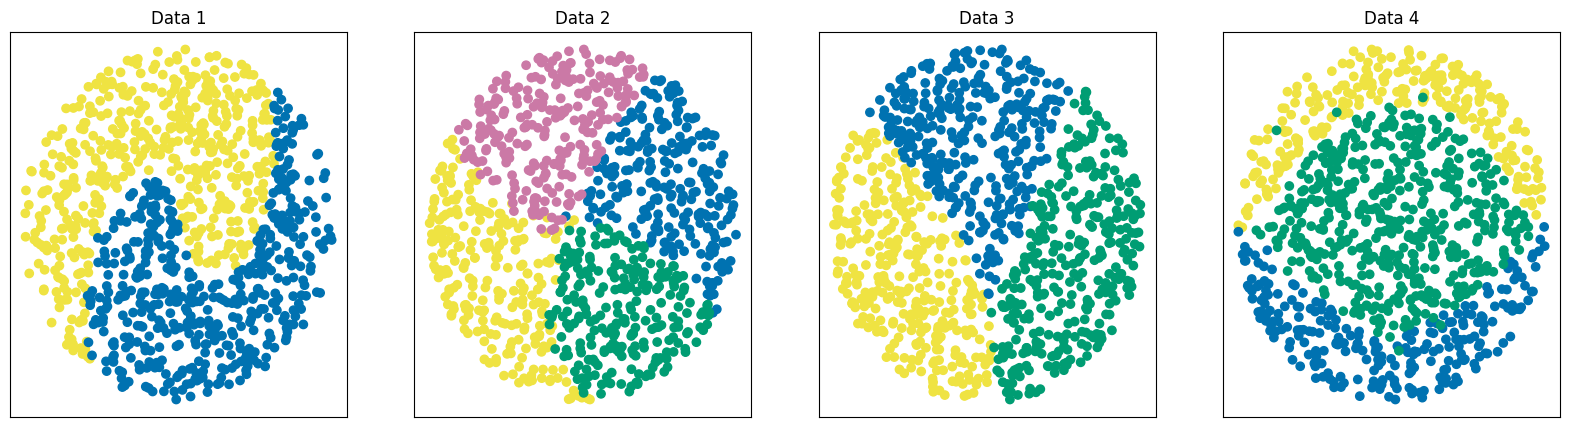

In [ ]:
data1_pushed = LAM1.X_pushed
data2_pushed = LAM2.X_pushed
data3_pushed = LAM3.X_pushed
data4_pushed = LAM4.X_pushed

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data_pushed, data in zip([0, 1, 2, 3], [data1_pushed, data2_pushed, data3_pushed, data4_pushed], [data1, data2, data3, data4]):
    axs[i].scatter(data_pushed[data[1] == 0, 0], data_pushed[data[1] == 0, 1], c=[colour['y'] for _ in range(data_pushed[data[1] == 0].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 1, 0], data_pushed[data[1] == 1, 1], c=[colour['b'] for _ in range(data_pushed[data[1] == 1].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 2, 0], data_pushed[data[1] == 2, 1], c=[colour['g'] for _ in range(data_pushed[data[1] == 2].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 3, 0], data_pushed[data[1] == 3, 1], c=[colour['p'] for _ in range(data_pushed[data[1] == 3].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 4, 0], data_pushed[data[1] == 4, 1], c=[colour['lb'] for _ in range(data_pushed[data[1] == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [11]:
def k_medoids(X, k, max_iter=100):
    """
    K-Medoids clustering algorithm
    :param X: numpy array of shape (n_samples, n_features)
    :param k: Number of clusters
    :param max_iter: Maximum number of iterations
    :return: (medoids, labels)
    """
    n_samples = X.shape[0]
    
    # Randomly initialize k medoids
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoid_indices]
    
    for _ in range(max_iter):
        # Compute distance matrix
        distances = pairwise_distances(X, medoids, metric='manhattan')
        
        # Assign labels based on closest medoid
        labels = np.argmin(distances, axis=1)
        
        # Update medoids
        new_medoids = np.copy(medoids)
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            
            # Compute cost for each cluster point as new medoid
            costs = np.sum(pairwise_distances(cluster_points, cluster_points, metric='manhattan'), axis=1)
            new_medoids[i] = cluster_points[np.argmin(costs)]
        
        # Check for convergence
        if np.all(new_medoids == medoids):
            break
        medoids = new_medoids
    
    return medoids, labels


def k_medoids_LAM(data, k, LAM, max_iter=1000):
    # initialize medoids
    medoids = data[torch.randperm(data.size(0))[:k]]
    n = data.shape[0]
    
    for i in range(max_iter):
        # calculate distances
        idx, dists = LAM.query(medoids)
        
        dists = dists[idx < n].reshape(k, n)

        idx, sort_idx = torch.sort(idx, dim=1)
        for _ in range(k):
            dists[_] = dists[_, sort_idx[_]]

        # assign medoids
        _, assignments = dists.min(dim=0)
        new_medoids = torch.clone(medoids)
        # update medoids
        for j in range(k):
            
            # get indices of all points in the cluster j
            cluster_points = idx[j, assignments == j]

            if len(cluster_points) == 0:
                continue

            # get distance matrix of LAM
            distance_matrix = LAM.dist_matrix

            # only take rows and columns where cluster_points is True
            distance_matrix = distance_matrix[cluster_points][:, cluster_points]

            distance_matrix = torch.tensor(distance_matrix, dtype=torch.float32)
            # sum over all columns
            sum = torch.sum(distance_matrix, dim=1)

            #print(sum)
            # minimum of the sum is the new medoid centre
            new_medoids[j] = data[cluster_points][sum.argmin()]

            #print('Lowest value in iteration', i, 'is', sum.min(), 'at', new_medoids[j])
            medoids = new_medoids
    return medoids, assignments

In [21]:
# do clustering for all datasets with euclidean metric

medoids1_euc, labels1_euc = k_medoids(data1[0], 2)
medoids2_euc, labels2_euc = k_medoids(data2[0], 4)
medoids3_euc, labels3_euc = k_medoids(data3[0], 3)
medoids4_euc, labels4_euc = k_medoids(data4[0], 3)

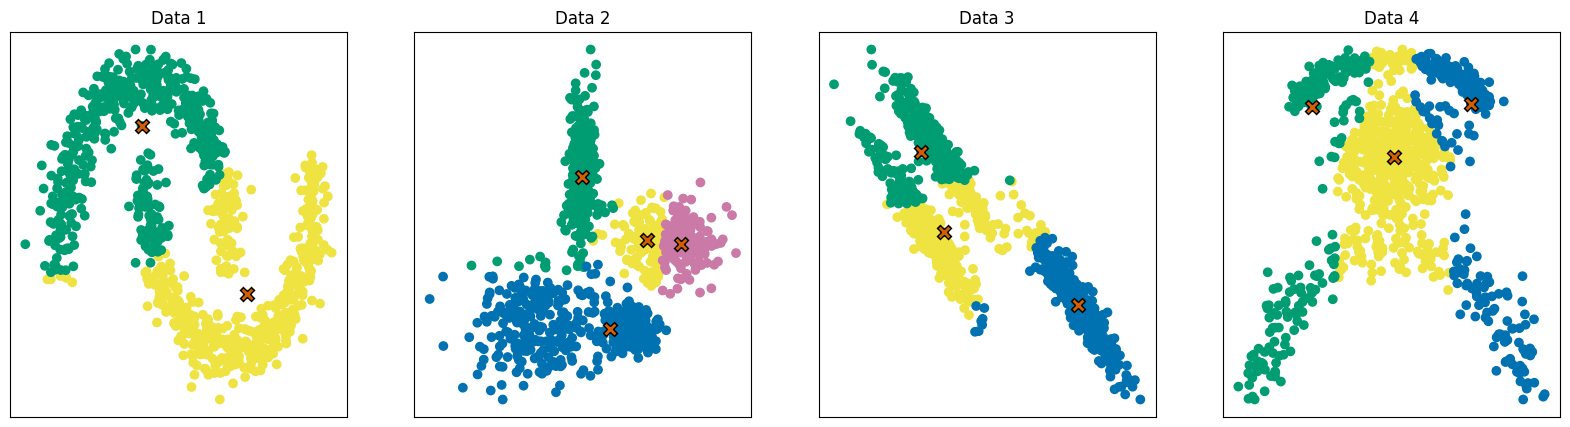

In [22]:
# plot clustering with euclidean
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_euc, medoids1_euc), (data2[0], labels2_euc, medoids2_euc), (data3[0], labels3_euc, medoids3_euc), (data4[0], labels4_euc, medoids4_euc)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [23]:
# same with LAM

medoids1_lam, labels1_lam = k_medoids_LAM(data1[0], 2, LAM1)
medoids2_lam, labels2_lam = k_medoids_LAM(data2[0], 4, LAM2)
medoids3_lam, labels3_lam = k_medoids_LAM(data3[0], 3, LAM3)
medoids4_lam, labels4_lam = k_medoids_LAM(data4[0], 3, LAM4)

H:\Uni\Master\Thesis\NFLAM\NFLAM\LAMINAR\LAMINAR\LAMINAR.py:189: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dists = torch.tensor(dist_matrix[idx_points]) # shape (m, n)


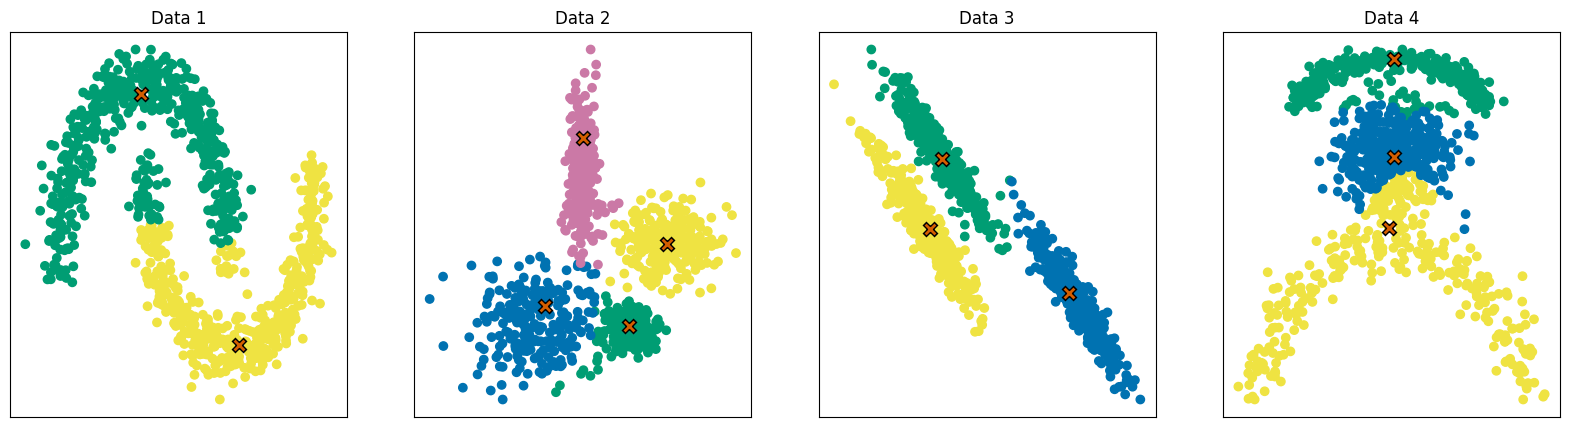

In [24]:
# plot clustering with LAM
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_lam, medoids1_lam), (data2[0], labels2_lam, medoids2_lam), (data3[0], labels3_lam, medoids3_lam), (data4[0], labels4_lam, medoids4_lam)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [25]:
def jaccard(points1, points2):
    n = len(points1)
    m = len(points2)
    intersection = len(set(points1.numpy()).intersection(set(points2.numpy())))

    if m + n - intersection == 0:
        return np.round(0.0, 2)
    else:
        return np.round(intersection / (n + m - intersection), 2)

In [26]:
# calculate jaccard index for all datasets

for i, d, euc_lab, lam_lab in zip([0, 1, 2, 3], [data1, data2, data3, data4], [labels1_euc, labels2_euc, labels3_euc, labels4_euc], [labels1_lam, labels2_lam, labels3_lam, labels4_lam]):
    print('Data ', i+1)
    print('\n')
    
    # get indices of the points with certain labels
    gt_idx_1 = torch.where(d[1] == 0)[0]
    gt_idx_2 = torch.where(d[1] == 1)[0]
    gt_idx_3 = torch.where(d[1] == 2)[0]
    gt_idx_4 = torch.where(d[1] == 3)[0]

    # get indices of the points with certain labels
    euclidean_idx_1 = torch.where(torch.tensor(euc_lab) == 0)[0]
    euclidean_idx_2 = torch.where(torch.tensor(euc_lab) == 1)[0]
    euclidean_idx_3 = torch.where(torch.tensor(euc_lab) == 2)[0]
    euclidean_idx_4 = torch.where(torch.tensor(euc_lab) == 3)[0]

    # sma for lam
    lam_idx_1 = torch.where(lam_lab == 0)[0]
    lam_idx_2 = torch.where(lam_lab == 1)[0]
    lam_idx_3 = torch.where(lam_lab == 2)[0]
    lam_idx_4 = torch.where(lam_lab == 3)[0]

    print('Euclidean')
    print(jaccard(gt_idx_1, euclidean_idx_1), jaccard(gt_idx_2, euclidean_idx_1), jaccard(gt_idx_3, euclidean_idx_1), jaccard(gt_idx_4, euclidean_idx_1))
    print(jaccard(gt_idx_1, euclidean_idx_2), jaccard(gt_idx_2, euclidean_idx_2), jaccard(gt_idx_3, euclidean_idx_2), jaccard(gt_idx_4, euclidean_idx_2))
    print(jaccard(gt_idx_1, euclidean_idx_3), jaccard(gt_idx_2, euclidean_idx_3), jaccard(gt_idx_3, euclidean_idx_3), jaccard(gt_idx_4, euclidean_idx_3))   
    print(jaccard(gt_idx_1, euclidean_idx_4), jaccard(gt_idx_2, euclidean_idx_4), jaccard(gt_idx_3, euclidean_idx_4), jaccard(gt_idx_4, euclidean_idx_4))

    print('\n')

    print('LAM')
    print(jaccard(gt_idx_1, lam_idx_1), jaccard(gt_idx_2, lam_idx_1), jaccard(gt_idx_3, lam_idx_1), jaccard(gt_idx_4, lam_idx_1))
    print(jaccard(gt_idx_1, lam_idx_2), jaccard(gt_idx_2, lam_idx_2), jaccard(gt_idx_3, lam_idx_2), jaccard(gt_idx_4, lam_idx_2))
    print(jaccard(gt_idx_1, lam_idx_3), jaccard(gt_idx_2, lam_idx_3), jaccard(gt_idx_3, lam_idx_3), jaccard(gt_idx_4, lam_idx_3))
    print(jaccard(gt_idx_1, lam_idx_4), jaccard(gt_idx_2, lam_idx_4), jaccard(gt_idx_3, lam_idx_4), jaccard(gt_idx_4, lam_idx_4))

    print('\n')



    

Data  1


Euclidean
0.09 0.72 0.0 0.0
0.71 0.09 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


LAM
0.02 0.87 0.0 0.0
0.88 0.05 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


Data  2


Euclidean
0.0 0.44 0.0 0.01
0.02 0.01 0.0 0.91
0.47 0.0 0.5 0.01
0.0 0.54 0.0 0.0


LAM
0.0 0.98 0.0 0.0
0.03 0.0 0.94 0.0
0.9 0.0 0.0 0.02
0.0 0.01 0.0 0.94


Data  3


Euclidean
0.52 0.15 0.04 0.0
0.16 0.57 0.0 0.0
0.01 0.0 0.91 0.0
0.0 0.0 0.0 0.0


LAM
1.0 0.0 0.0 0.0
0.0 0.99 0.0 0.0
0.0 0.0 0.99 0.0
0.0 0.0 0.0 0.0


Data  4


Euclidean
0.06 0.1 0.72 0.0
0.28 0.23 0.03 0.0
0.29 0.23 0.04 0.0
0.0 0.0 0.0 0.0


LAM
0.0 0.74 0.12 0.0
0.87 0.0 0.05 0.0
0.0 0.0 0.75 0.0
0.0 0.0 0.0 0.0


